In [1]:
%pip install torchinfo dagshub mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import dagshub
import mlflow

# 1. Menghubungkan VS Code ke repo DagsHub kamu
dagshub.init(repo_owner='Bedi002', repo_name='mobilenetv4-attention-deepfake', mlflow=True)

# 2. Mengatur MLflow agar mengirim data grafik ke web DagsHub
mlflow.set_tracking_uri("https://dagshub.com/Bedi002/mobilenetv4-attention-deepfake.mlflow")

print("✅ MLflow berhasil terhubung ke DagsHub!")

Accessing as Bedi002

Initialized MLflow to track repo "Bedi002/mobilenetv4-attention-deepfake"

Repository Bedi002/mobilenetv4-attention-deepfake initialized!

✅ MLflow berhasil terhubung ke DagsHub!


In [3]:
import torch
import torch.nn as nn
import timm
import torch.optim as optim

# ==========================================
# 1. MODUL ATTENTION (TETAP SAMA)
# ==========================================
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv1(x))

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        return out * self.sa(out)

# ==========================================
# 2. ARSITEKTUR UTAMA (YANG DIPERBAIKI)
# ==========================================
class MobileNetV4_CBAM(nn.Module):
    def __init__(self, num_classes=2):
        super(MobileNetV4_CBAM, self).__init__()
        
        # A. Panggil Backbone
        self.backbone = timm.create_model('mobilenetv4_conv_medium', pretrained=True, num_classes=0, global_pool='')
        
        # B. [PERBAIKAN] Deteksi Channel Otomatis!
        # Kita masukkan 1 gambar acak (dummy) untuk melihat wujud asli outputnya
        dummy_input = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            dummy_output = self.backbone(dummy_input)
            
        feature_dim = dummy_output.shape[1] # Pasti akan terbaca 1280
        print(f"✨ Deteksi Otomatis: Channel output sebenarnya adalah {feature_dim}")
        
        # C. Pasang CBAM dan Classifier dengan ukuran yang benar
        self.cbam = CBAM(feature_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# ==========================================
# 3. INISIALISASI ULANG MODEL & OPTIMIZER
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_proposed = MobileNetV4_CBAM(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
# Harus didefinisikan ulang di sini karena 'model_proposed' baru saja diganti "jeroannya"
optimizer_proposed = optim.AdamW(model_proposed.parameters(), lr=0.0001)

print("✅ Model Anti-Error Siap Dijalankan!")

✨ Deteksi Otomatis: Channel output sebenarnya adalah 1280
✅ Model Anti-Error Siap Dijalankan!


In [4]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Tentukan Path Dataset (Sesuaikan dengan lokasi folder di laptopmu)
base_dir = "./DATASET/real_vs_fake/real-vs-fake"

# 2. Pengaturan Transformasi Gambar
# Untuk Latih (Train) kita tambahkan sedikit variasi agar AI lebih pintar
# 2. Pengaturan Transformasi Gambar
# Untuk Latih (Train) kita berikan augmentasi ekstrem agar AI tidak menghafal pola
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), # Miringkan gambar
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Acak pencahayaan
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)), # Sesekali dibikin blur
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Untuk Validasi & Test (Cukup resize dan normalisasi saja - JANGAN DIUBAH)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Menghubungkan Kodingan ke Folder
train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), train_transforms)
valid_dataset = datasets.ImageFolder(os.path.join(base_dir, 'valid'), val_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(base_dir, 'test'), val_transforms)

# 4. Membuat DataLoader (Jembatan Data)
# Mengingat VRAM 1660 Super adalah 6GB, Batch Size 32 adalah angka yang aman
batch_size = 64

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2),
    'valid': DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2),
    'test':  DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
}

print(f"✅ Dataloader Berhasil Dibuat!")
print(f"Total Gambar Latih: {len(train_dataset):,}")
print(f"Total Gambar Validasi: {len(valid_dataset):,}")
print(f"Total Gambar Uji: {len(test_dataset):,}")

✅ Dataloader Berhasil Dibuat!
Total Gambar Latih: 9,632
Total Gambar Validasi: 1,204
Total Gambar Uji: 1,205


In [26]:
import time
import copy
import os
import sys
from tqdm.notebook import tqdm # Kita pakai tqdm.notebook biar rapi
import torch.optim as optim
import mlflow

In [ ]:
# 1. Tentukan Loss dan Optimizer BARU untuk model CBAM
criterion = torch.nn.CrossEntropyLoss()
optimizer_proposed = optim.AdamW(model_proposed.parameters(), lr=0.0001)

# 2. Fungsi Training Khusus CBAM
def train_model_cbam(model, criterion, optimizer, num_epochs=5):
    since = time.time()
    best_acc = 0.0
    
    if not os.path.exists('checkpoints'):
        os.makedirs('checkpoints')

    # --- TAMBAHAN: Mulai sesi pencatatan MLflow ---
    with mlflow.start_run(run_name="Training_MobileNetV4_CBAM_Baru"):
        # Log parameter dasar agar tercatat di DagsHub
        mlflow.log_param("model_architecture", "MobileNetV4_CBAM")
        mlflow.log_param("learning_rate", 0.0001)
        mlflow.log_param("epochs", num_epochs)
        mlflow.log_param("optimizer", "AdamW")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Bar Progres
            pbar = tqdm(dataloaders[phase], desc=f"{phase.upper()}", dynamic_ncols=True)
            
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase.upper()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Simpan CHECKPOINT KHUSUS CBAM
            if phase == 'valid':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), 'checkpoints/best_mobilenetv4_cbam_model.pth')
                    print("🌟 Model CBAM Terbaik Disimpan!")

    time_elapsed = time.time() - since
    print(f'\nTraining CBAM selesai dalam {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Akurasi Terbaik (Val): {best_acc:.4f}')
    
    return model

# 3. MULAI TRAINING (Tarik napas, siapkan GPU-mu!)
model_proposed = train_model_cbam(model_proposed, criterion, optimizer_proposed, num_epochs=5)

🏃 View run Training_MobileNetV4_CBAM_Baru at: https://dagshub.com/Bedi002/mobilenetv4-attention-deepfake.mlflow/#/experiments/0/runs/76f1aabb6fc245dbb369a0380faef625
🧪 View experiment at: https://dagshub.com/Bedi002/mobilenetv4-attention-deepfake.mlflow/#/experiments/0

Epoch 1/5
----------


TRAIN:   0%|          | 0/151 [00:00<?, ?it/s]

TRAIN Loss: 0.2919 Acc: 0.8919


VALID:   0%|          | 0/19 [00:00<?, ?it/s]

VALID Loss: 0.1944 Acc: 0.9095
🌟 Model CBAM Terbaik Disimpan!

Epoch 2/5
----------


...

VALID Loss: 0.2227 Acc: 0.9111

Epoch 5/5
----------


TRAIN:   0%|          | 0/151 [00:00<?, ?it/s]

TRAIN Loss: 0.1077 Acc: 0.9564


VALID:   0%|          | 0/19 [00:00<?, ?it/s]

VALID Loss: 0.1989 Acc: 0.9153

Training CBAM selesai dalam 5m 27s
Akurasi Terbaik (Val): 0.9186


Mulai mengevaluasi data test... (Tunggu sebentar ya)
✅ Evaluasi Selesai!

=== LAPORAN EVALUASI (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

        fake       0.99      0.82      0.89       596
        real       0.85      0.99      0.91       609

    accuracy                           0.90      1205
   macro avg       0.92      0.90      0.90      1205
weighted avg       0.92      0.90      0.90      1205



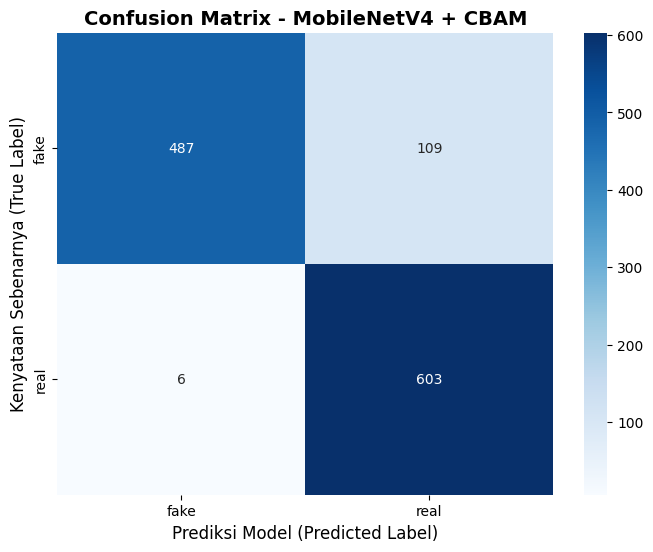

In [28]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Pastikan menggunakan model dengan bobot terbaik yang baru saja kita simpan
model_proposed.load_state_dict(torch.load('checkpoints/best_mobilenetv4_cbam_model.pth'))
model_proposed.eval() # Mode evaluasi (penting agar bobot tidak berubah)

y_true = []
y_pred = []

print("Mulai mengevaluasi data test... (Tunggu sebentar ya)")

# Matikan perhitungan gradien agar memori tidak penuh dan proses lebih cepat
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model_proposed(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("✅ Evaluasi Selesai!\n")

# 1. Menampilkan Laporan Metrik Lengkap (Classification Report)
print("=== LAPORAN EVALUASI (CLASSIFICATION REPORT) ===")
# Sesuaikan nama kelas dengan folder datasetmu (biasanya 0: fake, 1: real)
class_names = test_dataset.classes 
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Membuat Visualisasi Confusion Matrix (Tabel Biru)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediksi Model (Predicted Label)', fontsize=12)
plt.ylabel('Kenyataan Sebenarnya (True Label)', fontsize=12)
plt.title('Confusion Matrix - MobileNetV4 + CBAM', fontsize=14, fontweight='bold')
plt.show()

In [29]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# 1. Siapkan aturan pemrosesan gambar (HARUS SAMA dengan data validasi)
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Buat fungsi deteksi
def prediksi_gambar_luar(image_path, model, class_names):
    # Buka gambar menggunakan PIL
    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"❌ Gagal membuka gambar. Pastikan path/nama file benar! Error: {e}")
        return

    # Ubah gambar jadi tensor dan tambahkan dimensi Batch (karena AI minta format Batch)
    img_tensor = inference_transform(img).unsqueeze(0).to(device)
    
    # Matikan mode training
    model.eval()
    
    # Lakukan Prediksi
    with torch.no_grad():
        outputs = model(img_tensor)
        
        # Hitung probabilitas (persentase keyakinan AI) menggunakan Softmax
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted_class_idx = torch.max(probabilities, 1)
        
        # Ambil nama kelas dan persentasenya
        predicted_label = class_names[predicted_class_idx.item()]
        confidence_score = confidence.item() * 100
        
    # 3. Tampilkan Hasilnya
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    
    # Beri warna judul: Hijau kalau Yakin > 80%, Merah kalau ragu-ragu
    color = 'green' if confidence_score > 80 else 'red'
    plt.title(f"Prediksi: {predicted_label.upper()}\nKeyakinan AI: {confidence_score:.2f}%", 
              fontsize=14, fontweight='bold', color=color)
    plt.show()

print("✅ Fungsi prediksi gambar luar siap digunakan!")

✅ Fungsi prediksi gambar luar siap digunakan!


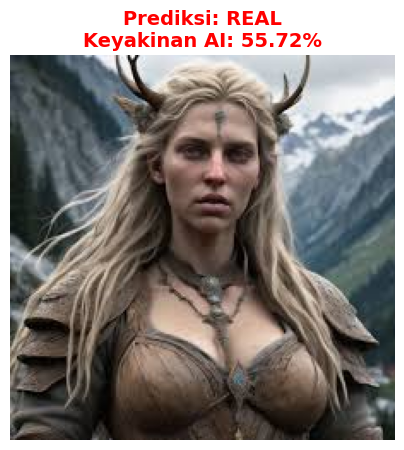

In [42]:
# Sesuaikan 'foto_test1.jpg' dengan nama file fotomu
# Sesuaikan 'class_names' jika modelmu terbalik mendeteksinya (misal: ['fake', 'real'])

class_names = test_dataset.classes # Mengambil nama kelas bawaan dataset
path_gambar = 'test/ai.jpeg'

prediksi_gambar_luar(path_gambar, model_proposed, class_names)